In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver


In [7]:
load_dotenv()

llm_model = ChatOpenRouter(
    model='nvidia/nemotron-3-nano-30b-a3b:free'
)

In [8]:
# define state

class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [9]:
def generate_joke(state:JokeState):
    
    prompt = f'generate a joke on the topic {state['topic']}'

    response = llm_model.invoke(prompt).content

    return {'joke': response}

In [10]:
def generate_explanation(state:JokeState):

    prompt = f'Write a explanation for the joke - {state['joke']}'

    response = llm_model.invoke(prompt).content

    return {'explanation': response}



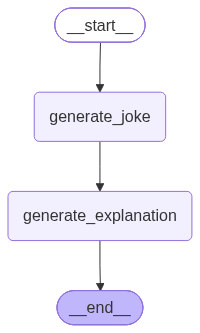

In [12]:
# define graph 
graph = StateGraph(JokeState)

# add node
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# add edge 
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [17]:
config1 = {'configurable': {"thread_id" : 1}}
workflow.invoke({'topic':'india'}, config=config1)

{'topic': 'india',
 'joke': "Sure! Here's a light‑hearted, friendly chuckle‑worthy line about India:\n\n> **Why did the Indian chef get a promotion at the restaurant?**  \n> Because every time the boss asked for “extra spice,” they literally added a whole new *curry* of ideas! 🌶️😊\n\n*(A little play on the love for spice and the endless variety of Indian cuisine—no offense intended, just a tasty pun!)*",
 'explanation': '**What makes the line funny?\n\n| Element | What it is | Why it works here |\n|---------|------------|-------------------|\n| **Setup** | “Sure! Here’s a light‑hearted, friendly chuckle‑worthy line about India:” | It signals that the speaker is about to deliver a playful, tongue‑in‑cheek comment rather than a serious critique. The tone is already self‑aware and “joke‑ish.” |\n| **Punchline** | “Why did the Indian chef get a promotion at the restaurant? Because every time the boss asked for ‘extra\u202fspice,’ they literally added a whole new *curry* of ideas.” | 1. **W

In [18]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'india', 'joke': "Sure! Here's a light‑hearted, friendly chuckle‑worthy line about India:\n\n> **Why did the Indian chef get a promotion at the restaurant?**  \n> Because every time the boss asked for “extra spice,” they literally added a whole new *curry* of ideas! 🌶️😊\n\n*(A little play on the love for spice and the endless variety of Indian cuisine—no offense intended, just a tasty pun!)*", 'explanation': '**What makes the line funny?\n\n| Element | What it is | Why it works here |\n|---------|------------|-------------------|\n| **Setup** | “Sure! Here’s a light‑hearted, friendly chuckle‑worthy line about India:” | It signals that the speaker is about to deliver a playful, tongue‑in‑cheek comment rather than a serious critique. The tone is already self‑aware and “joke‑ish.” |\n| **Punchline** | “Why did the Indian chef get a promotion at the restaurant? Because every time the boss asked for ‘extra\u202fspice,’ they literally added a whole new *curry* 

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'india', 'joke': "Sure! Here's a light‑hearted, friendly chuckle‑worthy line about India:\n\n> **Why did the Indian chef get a promotion at the restaurant?**  \n> Because every time the boss asked for “extra spice,” they literally added a whole new *curry* of ideas! 🌶️😊\n\n*(A little play on the love for spice and the endless variety of Indian cuisine—no offense intended, just a tasty pun!)*", 'explanation': '**What makes the line funny?\n\n| Element | What it is | Why it works here |\n|---------|------------|-------------------|\n| **Setup** | “Sure! Here’s a light‑hearted, friendly chuckle‑worthy line about India:” | It signals that the speaker is about to deliver a playful, tongue‑in‑cheek comment rather than a serious critique. The tone is already self‑aware and “joke‑ish.” |\n| **Punchline** | “Why did the Indian chef get a promotion at the restaurant? Because every time the boss asked for ‘extra\u202fspice,’ they literally added a whole new *curry*

# Time Travel Demonstration

In [21]:
workflow.get_state({'configurable': {"thread_id":"1", "checkpoint_id":"1f1846ee-3af7-635c-8002-46459f12c39e"}})

StateSnapshot(values={'topic': 'india', 'joke': 'Why did the Indian chef win the sword fight?  \n\nBecause he always had a “curry‑sword” — it always left his opponent in a *spice* of defeat! 😄', 'explanation': '**Explanation of the joke**\n\n| Part of the joke | What it’s pointing to | Why it’s funny |\n|------------------|----------------------|----------------|\n| **“Why did the Indian chef win the sword fight?”** | Sets up a classic “why‑did‑X‑do‑Y?” riddle format that signals a punch‑line is coming. | It creates an expectation that the answer will involve something uniquely Indian and culinary. |\n| **“Because he always had a ‘curry‑sword’…”** | A **pun** that fuses two words: *curry* (a spiced Indian dish) and *sword* (the weapon used in a duel). By blending them into “curry‑sword,” the joke pretends that the weapon itself is a curry‑flavored blade. | The unexpected mash‑up is surprising and delightful. It also gives a visual of a sword that looks like a ladle or a skewer dripping

In [22]:
workflow.invoke(None,{'configurable': {"thread_id":"1", "checkpoint_id":"1f1846ee-3af7-635c-8002-46459f12c39e"}})

{'topic': 'india',
 'joke': 'Why did the Indian chef win the sword fight?  \n\nBecause he always had a “curry‑sword” — it always left his opponent in a *spice* of defeat! 😄',
 'explanation': '**Explanation of the joke**\n\n| Part of the joke | What it’s pointing to | Why it’s funny |\n|------------------|----------------------|----------------|\n| **“Why did the Indian chef win the sword fight?”** | Sets up a classic “why‑did‑X‑do‑Y?” riddle format that signals a punch‑line is coming. | It creates an expectation that the answer will involve something uniquely Indian and culinary. |\n| **“Because he always had a ‘curry‑sword’…”** | A **pun** that fuses two words: *curry* (a spiced Indian dish) and *sword* (the weapon used in a duel). By blending them into “curry‑sword,” the joke pretends that the weapon itself is a curry‑flavored blade. | The unexpected mash‑up is surprising and delightful. It also gives a visual of a sword that looks like a ladle or a skewer dripping with sauce — an ab

In [23]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'india', 'joke': 'Why did the Indian chef win the sword fight?  \n\nBecause he always had a “curry‑sword” — it always left his opponent in a *spice* of defeat! 😄', 'explanation': '**Explanation of the joke**\n\n| Part of the joke | What it’s pointing to | Why it’s funny |\n|------------------|----------------------|----------------|\n| **“Why did the Indian chef win the sword fight?”** | Sets up a classic “why‑did‑X‑do‑Y?” riddle format that signals a punch‑line is coming. | It creates an expectation that the answer will involve something uniquely Indian and culinary. |\n| **“Because he always had a ‘curry‑sword’…”** | A **pun** that fuses two words: *curry* (a spiced Indian dish) and *sword* (the weapon used in a duel). By blending them into “curry‑sword,” the joke pretends that the weapon itself is a curry‑flavored blade. | The unexpected mash‑up is surprising and delightful. It also gives a visual of a sword that looks like a ladle or a skewer dripping

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'india', 'joke': 'Why did the Indian chef win the sword fight?  \n\nBecause he always had a “curry‑sword” — it always left his opponent in a *spice* of defeat! 😄', 'explanation': '**Explanation of the joke**\n\n| Part of the joke | What it’s pointing to | Why it’s funny |\n|------------------|----------------------|----------------|\n| **“Why did the Indian chef win the sword fight?”** | Sets up a classic “why‑did‑X‑do‑Y?” riddle format that signals a punch‑line is coming. | It creates an expectation that the answer will involve something uniquely Indian and culinary. |\n| **“Because he always had a ‘curry‑sword’…”** | A **pun** that fuses two words: *curry* (a spiced Indian dish) and *sword* (the weapon used in a duel). By blending them into “curry‑sword,” the joke pretends that the weapon itself is a curry‑flavored blade. | The unexpected mash‑up is surprising and delightful. It also gives a visual of a sword that looks like a ladle or a skewer drippin